## Atividade 1 — Preparação dos Dados

Carregue o dataset e recodifique o rótulo de classe para valores numéricos bipolares:
+1 para *good* e −1 para *bad*. Verifique se há valores ausentes ou atributos constantes
que devam ser removidos antes do treinamento. Em seguida, normalize todos os atributos
utilizando a padronização Z-score. Justifique algebricamente a necessidade da normalização
para que o processo da Regra Delta seja estável.

In [7]:
!pip install -U ucimlrepo

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix)

import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

In [ ]:
# plt.rcParams["font.family"]       = "Arial"
# plt.rcParams["mathtext.fontset"]  = "custom"
# plt.rcParams['mathtext.rm']       = "Arial"
# plt.rcParams['mathtext.it']       = "Arial:italic"
# plt.rcParams['mathtext.bf']       = "Arial:bold"
# plt.rcParams['figure.figsize']    = (8, 5)

In [11]:
ionosphere = fetch_ucirepo(id=52)
X = ionosphere.data.features
y = ionosphere.data.targets

y_adaline = y.squeeze().map({'g': 1, 'b': -1}).values

df = pd.DataFrame(X)
df['target'] = y_adaline
df.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34,target
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,1
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,-1
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,1
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,-1
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,1


In [12]:
print(f'Valores ausentes: {X.isnull().sum().sum()}')

Valores ausentes: 0


In [13]:
variances     = X.var()
constant_cols = variances[variances == 0].index.tolist()
print(f'Atributos constantes: {constant_cols}')

Atributos constantes: ['Attribute2']


In [14]:
if constant_cols:
    X = X.drop(columns=constant_cols)
    print(f'Atributos removidos: {constant_cols}')

print(f'Shape final de X: {X.shape}')

Atributos removidos: ['Attribute2']
Shape final de X: (351, 33)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_adaline, test_size=0.2, random_state=42, stratify=y_adaline
)

# Normalização Z-score
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Amostras de treino : {X_train.shape[0]}')
print(f'Amostras de teste  : {X_test.shape[0]}')
print(f'Features           : {X_train.shape[1]}')

Amostras de treino : 280
Amostras de teste  : 71
Features           : 33


## Justificativa da Normalização Z-score

A Regra Delta atualiza os pesos pelo gradiente do erro quadrático:

$$\Delta w_j = \eta \cdot (d - \hat{y}) \cdot x_j$$

Para garantir convergência, a taxa de aprendizagem deve satisfazer [1]:

$$0 < \eta < \frac{2}{\lambda_{\max}}$$

onde $\lambda_{\max}$ é o maior autovalor da matriz de correlação das entradas.
Quando os atributos têm escalas muito diferentes, $\lambda_{\max} \gg \lambda_{\min}$,
o que impõe uma janela de $\eta$ muito estreita e causa oscilações no gradiente.

A normalização Z-score garante $\mu_j = 0$ e $\sigma_j = 1$ para todo $j$,
aproximando a matriz de correlação da identidade ($\lambda_{\max} \approx \lambda_{\min} \approx 1$)
e tornando a convergência estável para uma faixa ampla de $\eta$.

---


## Atividade 2 — Implementação da Rede Adaline

Implemente uma rede Adaline para a classificação. Separe os dados em 80% treino e 20%
teste com divisão estratificada. Realize um estudo sobre valores distintos da taxa de
aprendizagem (η = 10⁻⁴, 10⁻³, 10⁻², 5×10⁻², 10⁻¹), mantendo fixos o número máximo
de épocas (N = 200) e o conjunto de treino. Para cada valor, plote a curva de convergência
da função de perda em função das épocas de treinamento. Com base nos gráficos, selecione
um valor de η que proporciona convergência mais suave e que resulte em um valor menor
da função de perda.

In [16]:
from sklearn.metrics import mean_squared_error

taxas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
N_EPOCHS = 200

historicos = {}

for eta in taxas:
    clf = SGDClassifier(
        loss='squared_error',
        eta0=eta,
        learning_rate='constant',
        max_iter=1,
        shuffle=True,
        random_state=42,
        warm_start=True
    )
    curva = []
    for _ in range(N_EPOCHS):
        clf.partial_fit(X_train, y_train, classes=[-1, 1])
        mse = mean_squared_error(y_train, clf.decision_function(X_train))
        curva.append(mse)
    historicos[eta] = curva
    print(f'η = {eta:.0e} | MSE final: {curva[-1]:.4f}')

η = 1e-04 | MSE final: 0.3813
η = 1e-03 | MSE final: 0.3704
η = 1e-02 | MSE final: 0.4468
η = 5e-02 | MSE final: 710569749138426296270848.0000
η = 1e-01 | MSE final: 5545514731250315236999168.0000


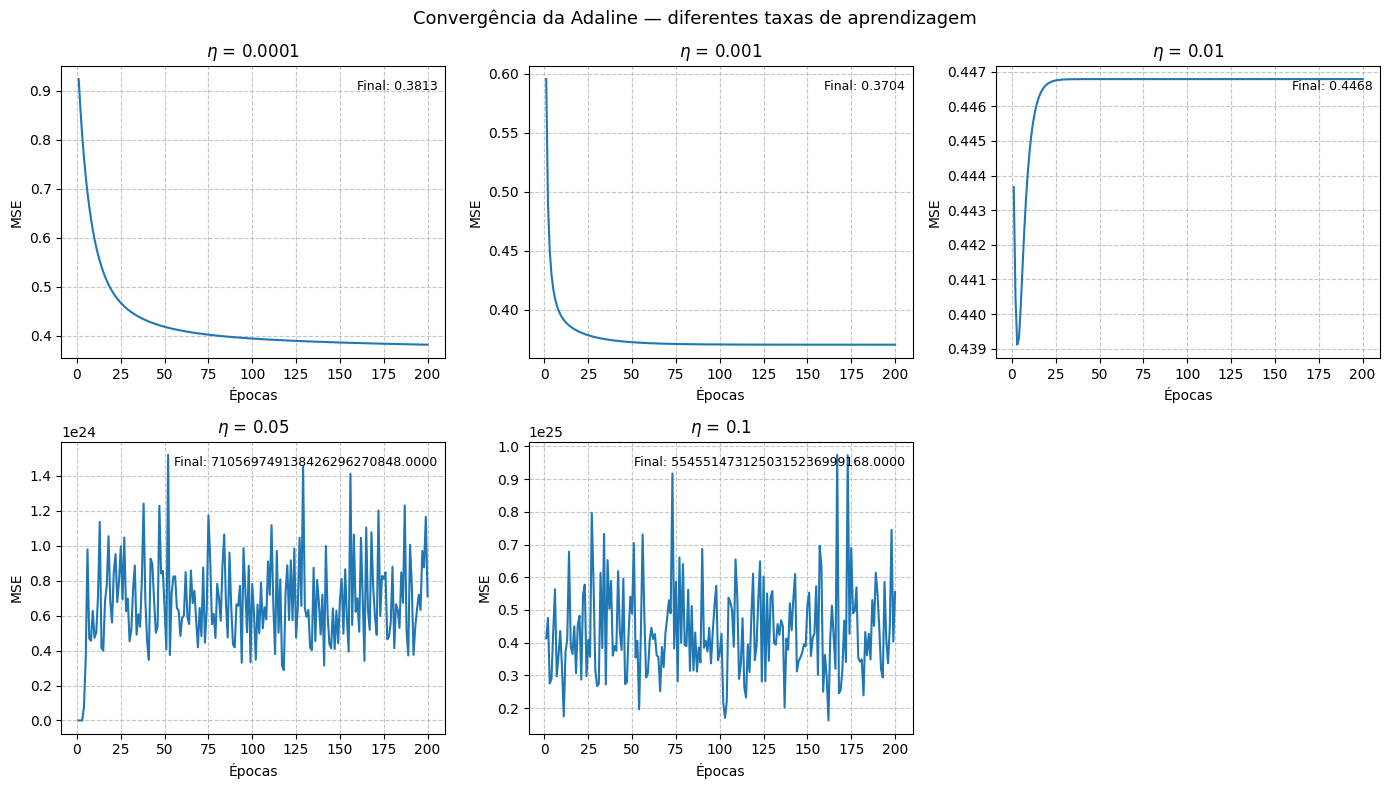

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

rotulos = [r'$\eta = 10^{-4}$', r'$\eta = 10^{-3}$', r'$\eta = 10^{-2}$',
           r'$\eta = 5 \times 10^{-2}$', r'$\eta = 10^{-1}$']

epochs = np.arange(1, N_EPOCHS + 1)

for i, (eta, rot) in enumerate(zip(taxas, rotulos)):
    axes[i].plot(epochs, historicos[eta])
    axes[i].set_title(f'$\\eta$ = {eta}')
    axes[i].set_xlabel('Épocas')
    axes[i].set_ylabel('MSE')
    axes[i].grid(linestyle='--', alpha=0.7)
    axes[i].text(0.98, 0.95, f'Final: {historicos[eta][-1]:.4f}',
                 transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=9)


fig.delaxes(axes[5])

plt.suptitle('Convergência da Adaline — diferentes taxas de aprendizagem', fontsize=13)
plt.tight_layout()
plt.show()

## Escolha do melhor η

Com base nas curvas de convergência, observa-se que:

- **η = 1e-4**: convergência lenta, MSE ainda elevado ao final das 200 épocas.
- **η = 1e-3**: convergência suave e estável, atingindo o menor MSE final (~0.37).
- **η = 1e-2**: converge rapidamente, porém estabiliza num MSE ligeiramente maior.
- **η = 5e-2** e **η = 1e-1**: instáveis — divergem completamente.

O valor **η = 1e-3** foi selecionado por proporcionar a melhor combinação entre
velocidade de convergência e estabilidade, resultando no menor MSE final sem oscilações.

## Atividade 3 — Avaliação do Modelo

Após treinar com o melhor η identificado na atividade anterior, classifique as amostras
de teste. Calcule e apresente a matriz de confusão, a acurácia global e as métricas de
precisão, *recall* e F1-score.

In [18]:
melhor_eta = 1e-3

modelo_final = SGDClassifier(
    loss='squared_error',
    eta0=melhor_eta,
    learning_rate='constant',
    max_iter=1,
    shuffle=True,
    random_state=42,
    warm_start=True
)

for _ in range(N_EPOCHS):
    modelo_final.partial_fit(X_train, y_train, classes=[-1, 1])

In [19]:
y_pred = modelo_final.predict(X_test)

print('Matriz de Confusão:')
print(confusion_matrix(y_test, y_pred))
print()
print(f'Acurácia : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precisão : {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred):.4f}')

Matriz de Confusão:
[[19  6]
 [ 0 46]]

Acurácia : 0.9155
Precisão : 0.8846
Recall   : 1.0000
F1-Score : 0.9388


## Resultados — Melhor η = 1e-3

### Matriz de Confusão

|                    | Previsto bad (−1) | Previsto good (+1) |
|--------------------|-------------------|--------------------|
| **Real bad (−1)**  | 19                | 6                  |
| **Real good (+1)** | 0                 | 46                 |

- **VP (Verdadeiro Positivo)**: 46 — sinais *good* corretamente classificados
- **VN (Verdadeiro Negativo)**: 19 — sinais *bad* corretamente classificados
- **FP (Falso Positivo)**: 6 — sinais *bad* classificados como *good*
- **FN (Falso Negativo)**: 0 — sinais *good* classificados como *bad*

### Métricas

| Métrica  | Valor  |
|----------|--------|
| Acurácia | 0.9155 |
| Precisão | 0.8846 |
| Recall   | 1.0000 |
| F1-Score | 0.9388 |

O modelo acertou **91,55%** das classificações. O Recall de **1.0** indica que
nenhum sinal *good* foi perdido (FN = 0). Os 6 erros foram todos Falsos Positivos
— sinais *bad* classificados como *good* — o que será discutido na Atividade 4.

## Atividade 4 — Análise Crítica: Qual erro é mais grave?
Com base na análise anterior, considerando que a classe *bad* representa ausência de
estrutura ionosférica — o que em sistemas operacionais pode indicar falha de transmissão
ou interferência — qual tipo de erro de classificação seria mais crítico em uma aplicação
real de monitoramento automático? Justifique.

---

No contexto do monitoramento ionosférico automático, existem dois tipos de erro:

- **Falso Positivo (FP)**: o modelo classifica um sinal *bad* como *good* —
  ou seja, indica que há estrutura ionosférica quando na verdade não há.

- **Falso Negativo (FN)**: o modelo classifica um sinal *good* como *bad* —
  ou seja, ignora uma janela de transmissão válida.

### O erro mais crítico: Falso Positivo (FP)

O **Falso Positivo** é o erro mais grave em uma aplicação real. Ao classificar
erroneamente um sinal *bad* como *good*, o sistema induz decisões operacionais
incorretas — como utilizar frequências ou estratégias de transmissão inadequadas
para as condições reais da ionosfera. Em sistemas de telecomunicação, GPS e
navegação, isso pode causar falhas de sinal não detectadas e comprometer
missões críticas.

O **Falso Negativo**, em contraste, é um erro mais seguro: o sistema simplesmente
deixa de aproveitar uma janela de transmissão válida, representando perda de
eficiência, mas sem risco operacional.

### Relação com as métricas obtidas

O modelo apresentou **Recall = 1.0** (nenhum FN) e **Precisão = 0.8846** (6 FP).
Embora os 6 Falsos Positivos representem o erro mais crítico, a alta acurácia
geral (91,55%) e o F1-Score de 0.9388 indicam que a Adaline obteve desempenho
satisfatório para este problema.